In [1]:
import pandas as pd
import pickle
%matplotlib inline

#Import style guide to make plots
import sys
sys.path.append('../../../../tjn_tools/')

from style_guide import *
#Import some data_processing tools to convert names to ISO3 
from data_processing import *

import seaborn as sns
import numpy as np
pd.options.mode.chained_assignment = None  # default='warn'

import pylab as plt
import matplotlib as mpl
%matplotlib inline

In [2]:
path_files = "../data/raw/"
path_files_final = "../data/final/"
path_files_temp = "../data/processing/"
path_figures = "../results/"

year_cbcr = 2017

In [3]:
## Input from notebook 1
etr_output = f"{path_files_final}{year_cbcr}_cbcr_etr_rates.xlsx"
df_etrs = pd.read_excel(etr_output,index_col=0)
iso3_to_etr = df_etrs["ETR_total"].to_dict()

iso3_to_gdp_output = f"{path_files_final}{year_cbcr}_iso3_to_gdp.dump"
iso3_to_gdp = pickle.load(open(f"{path_files_final}{year_cbcr}_iso3_to_gdp.dump","rb+"))

info_expenditures_output = f"{path_files_final}{year_cbcr}_info_expenditures.csv"
cols_other_info = ['who_gvt_health_expenditure','Govt_exp_educ_gdp_wb',
        'total_taxes_revenue', 'iso3', 'GDP_int', 'POP_int',
        'region_tjn']
other_info = pd.read_csv(info_expenditures_output, sep="\t", usecols=cols_other_info)

## Input from notebook 2
#Main results
final_data_output = f"{path_files_temp}{year_cbcr}_replicates.csv"

iso3_to_cit_output = f"{path_files_final}{year_cbcr}_iso3_to_cit.dump"
iso3_to_wages_output = f"{path_files_final}{year_cbcr}_iso3_to_wages.dump"

iso3_to_cit = pickle.load(open(iso3_to_cit_output,"rb+"))
iso3_to_wages = pickle.load(open(iso3_to_wages_output,"rb+"))




# Count of observations (foreign and domestic countries)
iso3_to_count_output = f"{path_files_final}{year_cbcr}_iso3_to_count.dump"
iso3_to_dom_output = f"{path_files_final}{year_cbcr}_iso3_to_dom.dump"
iso3_to_count = pickle.load(open(iso3_to_count_output,"rb+"))
iso3_to_dom = pickle.load(open(iso3_to_dom_output,"rb+"))

In [4]:
# Output
file_output = f"{year_cbcr}_tax_avoidance_sotj_table.xlsx"
sotj_table_output = f"{path_files_final}{file_output}"
sotj_table_output_workstream = f"../../../../../Workstreams/Scale of Tax Injustice/State of Tax Justice report/2021 Report/Tax avoidance/{file_output}"

In [5]:
def calculate_misalignment(df,
                           weights=[1/2,1/2,0,0],
                           pi_var="pi",
                           weights_var = ["revt","empt","t_at","wages"],
                          carve_out=None,
                          carve_out_perc=0,
                          thres_mis=0,
                          max_etr=0.25):
    """
    Calculate misalignment as a function of sales, employees, capital and wages
    
    In:
    df = data
    pi/rev/emp/cap/wages_var = variables with the profits/revenue/employees/capital/wages (None to discard)
    weights = weights of each of the variables. 
    
    Out:
    
    """
    
    #Make sure it is okay
    assert sum(weights)==1,"Weights need to sum up to 1"
    
    vars_keep = []
    weights_keep = []
    for i,var in enumerate(weights_var):
        if var is None:
            if weights[i] != 0:
                raise(Exception("Weight of None variable is nonzero"))
        else:
            if weights[i] > 0:
                vars_keep.append("share_{}".format(var))
                weights_keep.append(weights[i])
                df["share_{}".format(var)] = df[var]/df[var].sum()
    
#     print(weights_keep)
#     print(vars_keep)
    #Calculate the share of the economy
    df["share_economy"] = (df.loc[:,vars_keep]*weights_keep).sum(1,min_count=len(weights_keep))
    
    #Create carve out 
    if (carve_out is not None) and (carve_out_perc > 0):
        df[pi_var] = df[pi_var]-carve_out_perc*df[carve_out]
        df.loc[df[pi_var]<0,pi_var] = 0
    
    df["share_profits"] = df[pi_var]/df[pi_var].sum()
        
    #Theoretical profits
    df["pi_theo_mis"] = df[pi_var].sum()*df["share_economy"]
    
    #Misalignment
    df["misaligned_profits"] = df[pi_var]-df["pi_theo_mis"]

    #OVer threshold (x% of the profits can be misaligned)
    df.loc[(df["misaligned_profits"]>0)&(df["misaligned_profits"]<df["profits"]*thres_mis),"misaligned_profits"] = 0
    
    #Threshold adjustment
    df.loc[(df["misaligned_profits"]>0)&(df["etr"]>max_etr)&(df["Domestic"]!=1),"misaligned_profits"] = 0
    #Correct for discrepancies
    x = df["misaligned_profits"]

    pos_pr = x[x>0].sum()
    previous_pr = -x[x<0].sum()
#     print("Profit shifted {:2.1f} adjusted to {:2.1f}".format(previous_pr/1E9,pos_pr/1E9))
    df.loc[df["misaligned_profits"]<0,"misaligned_profits"] *= pos_pr/previous_pr



#     df["etr"] = df["p_iso3"].map(iso3_to_etr)
    
    #Total shifted (exclude resource-rich countries)
#     total_shifted = df.loc[(df["misaligned_profits"]>0)&(df["etr"]<0.15),"misaligned_profits"].sum() 
    
    return df

def plot_results(countries,w2c,restriction="Domestic MNCs",gains=False,show=True):
    """
    Plot the results for a set of countries
    
    ## Input
    countries: countries to plot (iso3)
    w2c: dictionary {country: color}
    restriction: domestic or mncs corporations
    gains: plot losses (False) or gains (True)
    show: show plot
    """
    
    if gains:
        mult = -1
    else:
        mult = 1

    plt.figure(figsize=(12,3))
    index = 0 
    cs = []
    title = ""
    for i,row in d.loc[d["iso3_d"].isin(countries)].iterrows():
        if restriction not in row["Domestic"]:
            continue
        cs.append(row["iso3_d"])
        for col in list(d.columns)[2:-1]:
            index += 1
            
            if row["iso3_d"] == sorted(countries)[-1]: #last coontry
                if isinstance(col,str):
                    label = col
                    title="Minimum misalignment"
       
                else:
                    if isinstance(col[0],str):
                        label = f"{col[0][:-5]} ({col[1]})"
                        title=["Variable","Carveout fraction"]                        
                    else:
                        label = [np.round(_,2) if _ != int(_) else int(_) for _ in col]
                        title=["Sales","Emp","Wages","TA"]
            else:
                label = None

            
            if isinstance(row[col],float):
                continue
            
            plt.scatter([index],[mult*100*row[col][2]],
                     color="k",label=None,zorder=9,s=5)                
            plt.plot([index,index],[mult*100*row[col][0],mult*100*row[col][4]],
                     color=w2c[col],lw=4,label=label,zorder=8)

        index += 5
        plt.plot([index-2,index-2],[mult*-15,mult*20],"--",color="lightgray")
    
    separation = len(list(d.columns)[2:-1])+5
    plt.plot([0,index],[0,0],"--",zorder=0,color="k")
    plt.gca().grid(axis="y")
    sns.despine(bottom=True,left=True)
    plt.ylabel("")
#     cs = sorted(countries)
    plt.xticks(range(3,separation*(len(cs)-1)+4,separation),[iso3_to_name(_).replace(" ","\n") for _ in cs])
    plt.xlim(0,index-4.5)

    # Put the legend out of the figure
    plt.legend(bbox_to_anchor=(1.05, 0.9), loc=2, borderaxespad=0.,frameon=False,title=title)
    if gains:
        plt.ylabel("Gains from formulary apportionment (% of GDP)")
    else:
        plt.ylabel("Profits shifted in (% of GDP)")
    plt.title(restriction)
    if show:
        plt.show()

def num(x):
    """
    Convert numbers of strings to floats
    """
    try:
        return float(x)
    except:
        return np.nan
    
    

In [6]:
#Read main results and add etr,cit,wages    

df = pd.read_csv(final_data_output,sep="\t").reset_index(drop=True)
for col in list(df.columns)[2:]:
    df[col] = df[col].apply(num)
df = df.dropna()

df["wages_pred"] = df["iso3_d"].map(iso3_to_wages)*df["emp_pred"]*12
df["etr"] = df["iso3_d"].map(iso3_to_etr)
df["cit"] = df["iso3_d"].map(iso3_to_cit)
df["gdp"] = df["iso3_d"].map(iso3_to_gdp)

df.head()

,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,n_rep,wages_pred,etr,cit,gdp
0,ARG,ARG,1.0,143735.000000,4.349976e+10,3.484462e+10,2.881636e+09,1.000000,143735.0,4.349976e+10,3.484462e+10,2.881636e+09,0.0,1.270559e+09,0.316518,0.35,5.295973e+11
1,ARG,AUS,0.0,2056.201913,9.354030e+08,2.561310e+08,6.202941e+07,1.115077,1844.0,8.388686e+08,2.296981e+08,5.562792e+07,0.0,1.817599e+07,0.316518,0.35,5.295973e+11
2,ARG,BMU,0.0,4784.795234,1.405206e+09,7.054575e+08,4.344638e+07,1.115077,4291.0,1.260188e+09,6.326537e+08,3.896267e+07,0.0,4.229565e+07,0.316518,0.35,5.295973e+11
3,ARG,BRA,0.0,23984.190324,3.955814e+09,1.476991e+09,6.320611e+08,1.115077,21509.0,3.547571e+09,1.324564e+09,5.668319e+08,0.0,2.120105e+08,0.316518,0.35,5.295973e+11
4,ARG,CHE,0.0,8872.667367,3.425587e+09,1.199473e+09,2.300156e+08,1.115077,7957.0,3.072064e+09,1.075686e+09,2.062778e+08,0.0,7.843078e+07,0.316518,0.35,5.295973e+11


In [23]:
#Test for finland
m = calculate_misalignment(df.loc[df["n_rep"]==1],weights=[0,0.5,0.5,0],
                                  weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                  carve_out=None,
                                  carve_out_perc=0,
                                  pi_var="profits",
                                 thres_mis=0,
                                 max_etr=0.15)
m = m.loc[m["iso3_o"]=="CHE",["iso3_d","share_economy","share_profits","misaligned_profits"]].sort_values(by="misaligned_profits")
m[["share_economy",'share_profits']] *= 1000
m.tail(10)

,iso3_d,share_economy,share_profits,misaligned_profits
3915,LKA,0.006315,0.010853,2.126328e+07
3120,NLD,0.127287,0.134212,3.245105e+07
3395,TWN,0.087641,0.099982,5.783186e+07
4056,UGA,0.013025,0.053673,1.904763e+08
2720,FIN,0.114995,0.256838,6.646784e+08
2584,CAN,0.182979,0.332195,6.992274e+08
2823,HKG,0.136422,0.306436,7.966921e+08
3289,SGP,0.204484,0.570445,1.714901e+09
2995,LUX,0.025551,0.579320,2.594977e+09
2602,CHE,3.932936,6.312453,1.115047e+10


,iso3_o,share_economy,share_profits,misaligned_profits
533,USA,0.306250,0.203345,-4.060018e+08
530,JPN,0.125532,0.039752,-3.384400e+08
527,FRA,0.127211,0.067815,-2.343445e+08
528,IND,0.025326,0.002536,-8.991687e+07
524,DNK,0.257395,0.245753,-4.593551e+07
534,ZAF,0.008620,-0.002327,-4.319056e+07
529,ITA,0.037350,0.027626,-3.836877e+07
519,AUS,0.004474,-0.000682,-2.034266e+07
522,CHN,0.011430,0.008219,-1.266869e+07
532,MEX,0.000832,0.000142,-2.723353e+06


In [9]:
temp_foreign = df.loc[df["Domestic"]==0]
temp_foreign["pi"].sum(),temp_foreign["profits"].sum(),(temp_foreign["profits"].sum()-temp_foreign["pi"].sum())/temp_foreign["pi"].sum()

(1627889711871686.8, 1951734556954369.5, 0.19893537180128626)

# 2. Main results

In [29]:
percentiles = [12.5,25,50,75,87.5]
main_weights = [0,0.5,0.5,0]

In [30]:
weigths = main_weights/np.sum(main_weights)
all_reps = []
for rep,data in df.groupby("n_rep"):
    data = calculate_misalignment(data,weights=weigths,
                                  weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                  carve_out=None,
                                  carve_out_perc=0,
                                  pi_var="profits",
                                 thres_mis=0,
                                 max_etr=0.15)
    data.loc[(data["Domestic"]==0)&(data["misaligned_profits"]<0),"Domestic"] = -1
    data["Domestic"] = data["Domestic"].map({1: "Domestic", 0: "Foreign (in)", -1: "Foreign (out)"})
    all_reps.append(data.groupby(["iso3_d","Domestic"])["misaligned_profits"].sum())

df_all_reps = pd.concat(all_reps,axis=1)

#Switch negative and positive (+ means loses now)
df_all_reps *= -1
df_all_reps

misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.776984e+07        2.287062e+07   
AFG    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -4.695763e+07       -4.688992e+07   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        1.761123e+09        1.571491e+09   
ZWE    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.171159e+08        2.626776e+08   

                      misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.519805e+07        1.526033e+07   
AFG    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -4.675114e+07       -4.696438e+07   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        1.915278e+09        1.795384e+09   
ZWE    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        3.908388e+08        2.365189e+08   

                      misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.146551e+07        1.862565e+07   
AFG    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -4.486476e+07       -4.144581e+07   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        1.648165e+09        1.676903e+09   
ZWE    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.724853e+08        2.420262e+08   

                      misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        1.574924e+07        2.810569e+07   
AFG    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -4.690528e+07       -4.698143e+07   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        1.704912e+09        1.635714e+09   
ZWE    Domestic            -0.000000e+00       -0.000000e+00   
       Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.651639e+08        2.388214e+08   

                      misaligned_profits  misaligned_profits  ...  \
iso3_d Domestic                                               ...   
ABW    Domestic            -0.000000e+00       -0.000000e+00  ...   
       Foreign (in)        -0.000000e+00       -0.000000e+00  ...   
       Foreign (out)        1.899724e+07        1.587705e+07  ...   
AFG    Domestic            -0.000000e+00       -0.000000e+00  ...   
       Foreign (in)        -4.426117e+07       -4.680699e+07  ...   
...                                  ...                 ...  ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00  ...   
       Foreign (out)        1.505373e+09        1.598584e+09  ...   


In [31]:
#Median profit shifted
boot_all_mis = df_all_reps.copy()
boot_all_mis[boot_all_mis<0] = 0

ci_profit_shifting = np.percentile(boot_all_mis.sum()/1E9,[2.5,50,97.5])
print("Profit shifting {1:2,.0f}B (95% CI {0:2,.0f}-{2:2,.0f}B)".format(*ci_profit_shifting))

Profit shifting 1,197B (95% CI 1,163-1,334B)


Profit shifting 1,197B (95% CI 1,163-1,334B)


In [32]:
# Create results
boot_all_mis_sum = pd.concat([df_all_reps.apply(lambda x: np.percentile(x[np.isfinite(x)],percentiles),axis=1),df_all_reps.median(1),df_all_reps.std(1)],axis=1)
boot_all_mis_sum.columns = ["Perc","Median","STD"]
boot_all_mis_sum["iso3"] = boot_all_mis_sum.index.get_level_values(0)
boot_all_mis_sum["MNCs"] = boot_all_mis_sum.index.get_level_values(1)
boot_all_mis_sum["Count_countries"] = boot_all_mis_sum["iso3"].map(iso3_to_count)
boot_all_mis_sum.loc[boot_all_mis_sum["MNCs"]=="Domestic","Count_countries"] = boot_all_mis_sum.loc[boot_all_mis_sum["MNCs"]=="Domestic","iso3"].map(iso3_to_dom).fillna(0)

boot_all_mis_sum["Three_ds"] = boot_all_mis_sum["Count_countries"]>=5

#Merge with health expenditure, etc
results = pd.merge(boot_all_mis_sum,
                   other_info)

results["etr"] = results["iso3"].map(iso3_to_etr)
results["cit"] = results["iso3"].map(iso3_to_cit)

results["Min"] = results["Perc"].str[0]
results["Q1"] = results["Perc"].str[1]
results["Q3"] = results["Perc"].str[3]
results["Max"] = results["Perc"].str[-1]

results["Noise"] = (results["Q3"]-results["Q1"])/results["Median"].abs()
results["Revenue_loss_etr"] = results["Median"]*results["etr"]
results["Revenue_loss_cit"] = results["Median"]*results["cit"]
results["Revenue_loss_etr_min"] = results["Min"]*results["etr"]
results["Revenue_loss_cit_min"] = results["Min"]*results["cit"]
results["Revenue_loss_etr_max"] = results["Max"]*results["etr"]
results["Revenue_loss_cit_max"] = results["Max"]*results["cit"]

results["CI_outside_zero"] = ((results["Min"]>0)|(results["Max"]<0)).astype(int) + (results["Three_ds"]).astype(int)



In [33]:
# Rename columns and keep only important info
big_table = results.loc[:,["iso3","MNCs","region_tjn","cit","etr","Median","Min","Max","Revenue_loss_cit","Revenue_loss_cit_min","Revenue_loss_cit_max","Revenue_loss_etr","Revenue_loss_etr_min","Revenue_loss_etr_max","CI_outside_zero","Three_ds","Count_countries","GDP_int","POP_int","who_gvt_health_expenditure","Govt_exp_educ_gdp_wb","total_taxes_revenue"]]
results["total_taxes_revenue"] = results["total_taxes_revenue"].replace(0,np.nan)
big_table.columns = ["Name","MNCs","Region","CIT","ETR","Profit loss (M)","Min. Profit loss (M)","Max. Profit loss (M)","Revenue loss using CIT (M)","Min. Revenue loss using CIT (M)","Max. Revenue loss using CIT (M)","Revenue loss using ETR (M)","Min Revenue loss using ETR (M)","Max. Revenue loss using ETR (M)","Robust","3+reporters","N_reporters","gdp","pop","health","educ","tax_revenue"]
big_table["Name"] = big_table["Name"].map(iso3_to_name)

for  col in ["gdp","health","educ","tax_revenue"]:
    big_table["Profit loss per {} (%)".format(col)] = (100*big_table["Profit loss (M)"]/big_table[col]).round(2)
    
big_table["Profit loss per pop ($ per capita)"] = (big_table["Profit loss (M)"].copy()/big_table["pop"]).astype(int)

#Convert to millinos
for col in big_table.columns:
    if "(M)" in col:
        big_table[col] /= 1E6

#Drop unnecesary columns
big_table = big_table.drop(columns=["health","educ","tax_revenue"])
big_table.head()

,Name,MNCs,Region,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),...,Robust,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita)
0,Aruba,Domestic,Caribbean/American isl.,0.25,0.153001,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,...,0,False,0.0,2.966542e+09,1.047770e+05,-0.00,NaN,-0.00,-0.00,0
1,Aruba,Foreign (in),Caribbean/American isl.,0.25,0.153001,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,...,0,False,4.0,2.966542e+09,1.047770e+05,-0.00,NaN,-0.00,-0.00,0
2,Aruba,Foreign (out),Caribbean/American isl.,0.25,0.153001,23.127754,17.982598,31.295693,5.781938,4.495649,...,1,False,4.0,2.966542e+09,1.047770e+05,0.78,NaN,12.80,3.61,220
3,Afghanistan,Domestic,Asia,0.20,0.076844,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,...,0,False,0.0,1.947716e+10,3.522628e+07,-0.00,-0.00,-0.00,-0.00,0
4,Afghanistan,Foreign (in),Asia,0.20,0.076844,-46.862890,-46.981445,-38.739202,-9.372578,-9.396289,...,1,False,3.0,1.947716e+10,3.522628e+07,-0.24,-49.18,-6.78,-3.05,-1


In [34]:
#Calculate regional averages
region_sum = big_table.copy()
for  col in ["health","educ","tax_revenue"]:
    region_sum["GDP_{}".format(col)] = region_sum["gdp"]*np.isfinite(region_sum["Profit loss per {} (%)".format(col)])
    region_sum["Profit loss per {} (%)".format(col)] = region_sum["Profit loss per {} (%)".format(col)]*region_sum["gdp"]/region_sum.groupby("Region")["gdp"].transform(sum)
    del region_sum["GDP_{}".format(col)]

for  col in ["ETR", "CIT"]:
    region_sum[col] = region_sum[col]*region_sum["gdp"]/region_sum.groupby("Region")["gdp"].transform(sum)
    
region_sum = region_sum.groupby("Region").sum().reset_index()
region_sum["Name"] = " "+region_sum["Region"]
region_sum["Profit loss per gdp (%)"] = 100*region_sum["Profit loss (M)"]*1E6/region_sum["gdp"]
region_sum["Profit loss per pop ($ per capita)"] = region_sum["Profit loss (M)"]*1E6/region_sum["pop"]
display(region_sum.head())


#Merge data
table = pd.concat([big_table,region_sum],sort=False).sort_values(by=["Region","Name"])
table = table.drop(columns=["Region"])


,Region,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),Max. Revenue loss using CIT (M),Revenue loss using ETR (M),...,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita),Name
0,Africa,0.273247,0.289592,34334.342571,21771.069336,47482.459595,11301.444946,8115.112860,14730.553643,12785.213924,...,61,683.0,6.984814e+12,3.398176e+09,0.491557,47.773479,10.034109,0.609167,10.103756,Africa
1,Asia,0.251787,0.253437,-99785.488544,-183237.993411,-27600.095803,-4172.981872,-21620.424038,11094.992921,16699.828564,...,72,990.0,8.677194e+13,1.327604e+10,-0.114997,2.671831,-4.265463,-0.404111,-7.516210,Asia
2,Caribbean/American isl.,0.267813,0.091749,-233951.639268,-277386.392584,-215619.387902,-16112.883399,-18683.736694,-14238.746546,-833.021981,...,18,245.0,6.461969e+11,5.541919e+07,-36.204389,-39.626802,-555.481473,-5.733167,-4221.491804,Caribbean/American isl.
3,Europe,0.244343,0.167423,-2207.361296,-55461.527471,48912.201979,25495.147155,15899.643672,35253.994810,41088.378828,...,88,1222.0,6.292439e+13,2.225162e+09,-0.003508,-0.991520,1.544384,0.181652,-0.992000,Europe
4,Latin America,0.311572,0.239799,73231.029659,66379.773112,80182.481458,22536.922654,20499.005622,24640.689518,17509.725746,...,35,532.0,1.646019e+13,1.811857e+09,0.444898,14.559213,6.756858,2.957382,40.417663,Latin America


In [35]:


#Quick rounding
for col in table.columns:
    if "Profit loss (M)" in col:
        table[col] = table[col].round(0).astype(int)
    elif "Revenue loss using" in col:
        table[col] = table[col].round(1)
    elif col in ["ETR","CIT"]:
        table[col] = (100*table[col]).round(2)
    elif "(%)" in col:
        table[col] = table[col].round(1)
    elif col in ['Profit loss per pop ($ per capita)',"gdp","pop"]:
        table[col] = table[col].round(0).astype(int)

#Reset index
table = table.reset_index(drop=True)
table.head()

,Name,MNCs,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),Max. Revenue loss using CIT (M),...,Robust,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita)
0,Africa,NaN,27.32,28.96,34334,21771,47482,11301.4,8115.1,14730.6,...,132,61,683.0,6984814143368,3398176003,0.5,47.8,10.0,0.6,10
1,Algeria,Domestic,25.00,14.91,808,163,1467,202.1,40.9,366.7,...,1,0,0.0,180052364452,40583203,0.4,10.1,NaN,3.2,19
2,Algeria,Foreign (in),25.00,14.91,-3806,-4207,-3399,-951.6,-1051.8,-849.7,...,2,1,11.0,180052364452,40583203,-2.1,-47.6,NaN,-14.8,-93
3,Algeria,Foreign (out),25.00,14.91,847,755,935,211.7,188.7,233.7,...,2,1,11.0,180052364452,40583203,0.5,10.6,NaN,3.3,20
4,Angola,Domestic,30.00,54.32,0,0,0,-0.0,-0.0,-0.0,...,0,0,0.0,111443730434,28901163,-0.0,-0.0,NaN,-0.0,0


In [36]:
#Add color/formatting
    
a = []
for i,row in table.iterrows():
    if row["Robust"]==2:
        a.append("background-color: #44b0c6")
    elif row["Robust"]==1:
        a.append("background-color: #94c9d4")
    else:
        a.append("background-color: white")
        
def robust(s):
    return a

def continent(s):
    if s["Name"][0] == " ":
        return ['font-weight: bold']*len(s)
    else:
        return ['']*len(s)
    


In [37]:
#table.style.apply(robust).apply(continent,axis=1)

In [38]:
big_table[big_table["Profit loss (M)"]>0].sum()

Name                                  ArubaAfghanistanAngolaAnguillaAlbaniaAndorraUn...
MNCs                                  Foreign (out)Foreign (out)Foreign (out)Foreign...
Region                                Caribbean/American isl.AsiaAfricaCaribbean/Ame...
CIT                                                                           52.727701
ETR                                                                           43.047258
Profit loss (M)                                                          1192698.319931
Min. Profit loss (M)                                                     1100825.169799
Max. Profit loss (M)                                                     1291276.075798
Revenue loss using CIT (M)                                                 312187.27418
Min. Revenue loss using CIT (M)                                           289487.111358
Max. Revenue loss using CIT (M)                                           336448.002995
Revenue loss using ETR (M)      

In [18]:
table.style.apply(robust).apply(continent,axis=1).to_excel(sotj_table_output,index=None)
table.style.apply(robust).apply(continent,axis=1).to_excel(sotj_table_output_workstream,index=None)

# 3. Robustness tests

In [39]:


ty2alpha = {"Domestic MNCs":0.5, "Foreign MNCs":1}
countries = "IRL, NLD, SGP, FRA, DEU, USA, BRA, IND, MEX, GHA, KEN, CHN".split(", ")
cou2col = dict(zip(countries,sns.color_palette("CMRmap",len(countries))))

In [40]:
for i in iso3_to_etr:
    if iso3_to_etr[i] < 0.15:
        if iso3_to_cit.get(i) is None:
            c = np.nan
        else:
            c = iso3_to_cit.get(i)
        if np.isnan(c) or (c < 0.25):
            continue
        print(f"{i}\t{iso3_to_etr[i]:5.2f}\t{c:5.2f}")

ASM	 0.09	 0.27
AUT	 0.11	 0.25
BRB	 0.01	 0.25
CAN	 0.13	 0.26
CPV	 0.07	 0.25
CRI	 0.12	 0.30
DZA	 0.15	 0.25
ESP	 0.15	 0.25
GHA	 0.11	 0.25
GNQ	 0.03	 0.35
GUM	 0.05	 0.35
KNA	 0.00	 0.33
LKA	 0.13	 0.28
LUX	 0.02	 0.27
MMR	 0.12	 0.25
NLD	 0.06	 0.25
PAN	 0.08	 0.25
PNG	 0.09	 0.30
PRI	 0.02	 0.39
SEN	 0.14	 0.30
SLB	 0.07	 0.30
SUR	 0.00	 0.36
UGA	 0.08	 0.30
URY	 0.15	 0.25
VEN	 0.08	 0.34


[1. 0. 0. 0.]
[0. 1. 0. 0.]
[0. 0. 1. 0.]
[0. 0. 0. 1.]
[0.33333333 0.16666667 0.16666667 0.33333333]
[0.5  0.25 0.25 0.  ]
[0.  0.5 0.5 0. ]


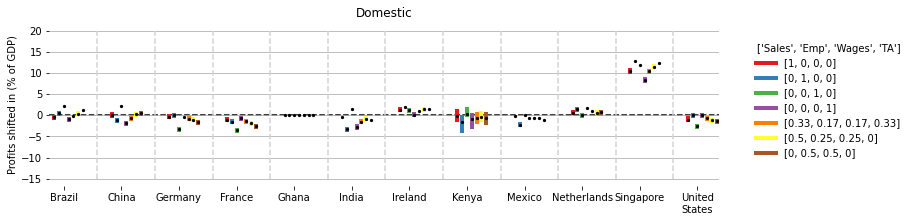

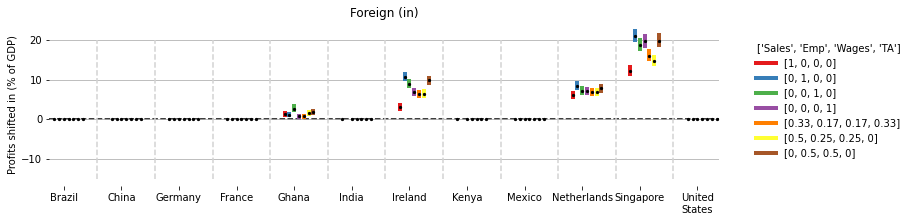

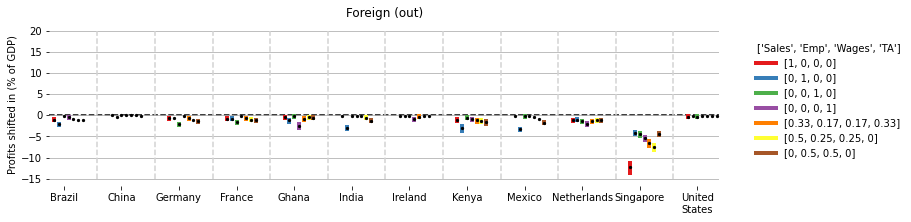

In [21]:

d_results = dict()
for weigths in [[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1],[1/3,1/6,1/6,1/3],[1/2,1/4,1/4,0],[0,0.5,0.5,0]]:
    weigths = weigths/np.sum(weigths)
    print(weigths)
    all_reps =  []
    all_pi =  []

    for rep,data in df.groupby("n_rep"):
        data = calculate_misalignment(data,weights=weigths,
                                      weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                      carve_out=None,
                                      carve_out_perc=0.2,
                                      pi_var="profits",
                                     thres_mis=0,
                                     max_etr=0.15)
        data.loc[(data["Domestic"]==0)&(data["misaligned_profits"]<0),"Domestic"] = -1
        data["Domestic"] = data["Domestic"].map({1: "Domestic", 0: "Foreign (in)", -1: "Foreign (out)"})
        all_reps.append(data.groupby(["iso3_d","Domestic"])["misaligned_profits"].sum())
#         all_pi.append(data.groupby(["iso3_d","Domestic"])["profits"].sum())

    df_all_reps = pd.concat(all_reps,axis=1)
#     df_all_pi = pd.concat(all_pi,axis=1)
    d_results[tuple(weigths)] = df_all_reps#[df_all_reps,df_all_pi]

all_w = []
for weights in d_results:
    d = d_results[weights].apply(lambda x: np.percentile(x[np.isfinite(x)],[2.5,25,50,75,97.5]).round(0),axis=1).reset_index()
    d[0] /= d["iso3_d"].map(iso3_to_gdp)    
    d[weights] = d[0]#.apply(lambda x: f"{x[1]:2.1%},{x[3]:2.1%}")

    del d[0]
    all_w.append(d.set_index(["iso3_d","Domestic"]))
    
d =  pd.concat(all_w,axis=1).reset_index()
# d["Domestic"] = d["Domestic"].replace({0:"Foreign MNCs", 1:"Domestic MNCs"})
d["etr"] = (100*d["iso3_d"].map(iso3_to_etr)).round(0)

w2c = dict(zip(d_results.keys(),sns.color_palette("Set1",7)))
plot_results(countries,w2c,restriction="Domestic")
plot_results(countries,w2c,restriction="Foreign (in)")
plot_results(countries,w2c,restriction="Foreign (out)")

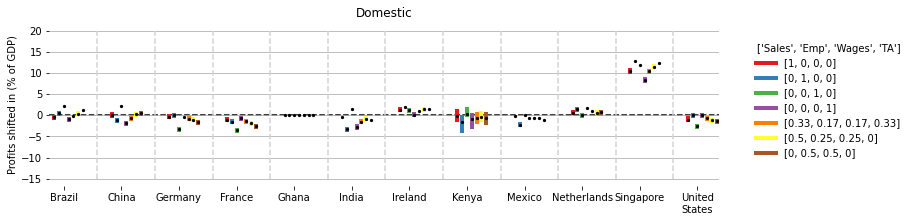

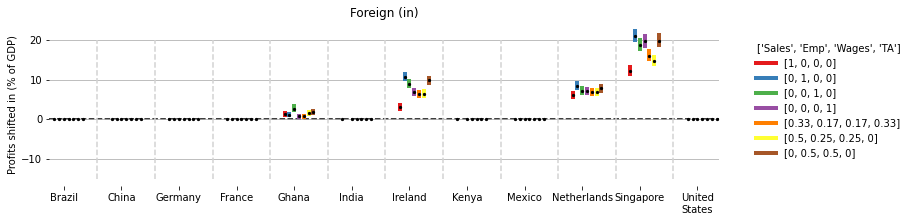

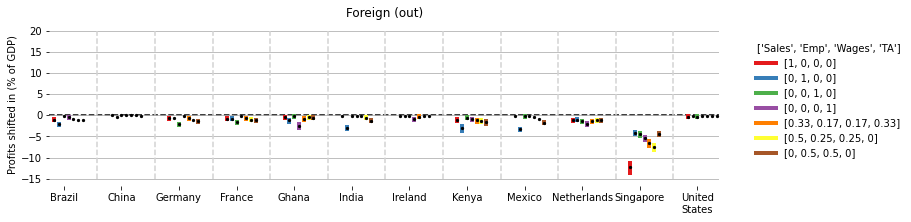

In [22]:
w2c = dict(zip(d_results.keys(),sns.color_palette("Set1",7)))
plot_results(countries,w2c,restriction="Domestic")
plot_results(countries,w2c,restriction="Foreign (in)")
plot_results(countries,w2c,restriction="Foreign (out)")

In [19]:
d = d_results[(0,0.5,0.5,0)].apply(lambda x: np.percentile(x[np.isfinite(x)],[2.5,25,50,75,97.5]).round(0),axis=1).reset_index()
d["ETR (%)"] = (100*d["iso3_d"].map(iso3_to_etr)).round(0)
d["cit"] = (100*d["iso3_d"].map(iso3_to_cit)).round(0)
d["gdp"] = (d["iso3_d"].map(iso3_to_gdp)).round(0)
d["sort"] = d[0].str[2]
d["PS (M)"] = d[0].str[2].apply(lambda x: f"{x/1E6:2,.0f}")
d["CI (M)"] = d.apply(lambda x: f"({x[0][0]/1E6:2,.0f}, {x[0][-1]/1E6:2,.0f})", axis=1)
d["PS (% GDP)"] = 100*d[0].str[2]/d["gdp"]
d["CI (% GDP)"] = d.apply(lambda x: f"({x[0][0]/x['gdp']:2.1%}, {x[0][-1]/x['gdp']:2.1%})", axis=1)
d["Type"] = d["Domestic"].map({0: "Foreign MNCs", 1: "Domestic MNCs"})
d["Country"] = d["iso3_d"].map(iso3_to_name)
display(d.sort_values(by="sort").tail(10)[["Country","Type","PS (M)", "PS (% GDP)", "CI (M)", "CI (% GDP)","ETR (%)"]])
display(d.sort_values(by="sort").head(10)[["Country","Type","PS (M)", "PS (% GDP)", "CI (M)", "CI (% GDP)","ETR (%)"]])

,Country,Type,PS (M),PS (% GDP),CI (M),CI (% GDP),ETR (%)
485,Singapore,NaN,"40,931",12.370142,"(40,681, 41,045)","(12.3%, 12.4%)",5.0
103,China,NaN,"51,230",0.434638,"(36,239, 58,639)","(0.3%, 0.5%)",26.0
334,Luxembourg,NaN,"56,103",86.721682,"(52,167, 61,706)","(80.6%, 95.4%)",2.0
98,Switzerland,NaN,"61,215",8.532647,"(58,274, 64,693)","(8.1%, 9.0%)",8.0
94,Canada,NaN,"63,662",3.739606,"(61,738, 64,554)","(3.6%, 3.8%)",13.0
234,Hong Kong,NaN,"64,170",20.105298,"(60,143, 68,597)","(18.8%, 21.5%)",8.0
486,Singapore,NaN,"65,887",19.912151,"(62,278, 70,100)","(18.8%, 21.2%)",5.0
413,Netherlands,NaN,"67,207",7.834594,"(62,205, 72,946)","(7.3%, 8.5%)",6.0
133,Cayman Islands,NaN,"136,859",2710.760379,"(131,204, 150,948)","(2598.8%, 2989.8%)",0.0
189,United Kingdom,NaN,"143,239",5.108127,"(140,480, 146,156)","(5.0%, 5.2%)",7.0


,Country,Type,PS (M),PS (% GDP),CI (M),CI (% GDP),ETR (%)
571,United States,NaN,"-249,043",-1.318329,"(-284,011, -234,247)","(-1.5%, -1.2%)",23.0
190,United Kingdom,NaN,"-96,927",-3.456589,"(-103,125, -93,570)","(-3.7%, -3.3%)",7.0
177,France,NaN,"-69,718",-2.619833,"(-75,407, -67,363)","(-2.8%, -2.5%)",25.0
141,Germany,NaN,"-62,643",-1.694579,"(-69,646, -59,708)","(-1.9%, -1.6%)",18.0
143,Germany,NaN,"-52,123",-1.409981,"(-57,064, -49,935)","(-1.5%, -1.4%)",18.0
188,United Kingdom,NaN,"-42,794",-1.526110,"(-47,366, -40,870)","(-1.7%, -1.5%)",7.0
573,United States,NaN,"-35,812",-0.189575,"(-38,520, -34,613)","(-0.2%, -0.2%)",23.0
179,France,NaN,"-32,273",-1.212761,"(-34,877, -30,750)","(-1.3%, -1.2%)",25.0
283,Japan,NaN,"-32,102",-0.635370,"(-42,440, -27,476)","(-0.8%, -0.5%)",27.0
255,India,NaN,"-29,720",-1.275650,"(-32,863, -27,518)","(-1.4%, -1.2%)",42.0


In [20]:
iso3_to_dom["CAN"]

1

In [21]:
d.loc[d["iso3_d"]=="BRA"]

,iso3_d,Domestic,0,ETR (%),cit,gdp,sort,PS (M),CI (M),PS (% GDP),CI (% GDP),Type,Country
77,BRA,Domestic,"[25571763613.0, 26452598633.0, 26671107222.0, ...",23.0,34.0,2.032767e+12,2.667111e+10,"26,671","(25,572, 27,230)",1.312059,"(1.3%, 1.3%)",NaN,Brazil
78,BRA,Foreign (in),"[0.0, 0.0, 0.0, 0.0, 0.0]",23.0,34.0,2.032767e+12,0.000000e+00,0,"( 0, 0)",0.000000,"(0.0%, 0.0%)",NaN,Brazil
79,BRA,Foreign (out),"[-25077343474.0, -23517777208.0, -23137959412....",23.0,34.0,2.032767e+12,-2.313796e+10,"-23,138","(-25,077, -22,188)",-1.138249,"(-1.2%, -1.1%)",NaN,Brazil


In [45]:
cost = []
costetr = []
mis = []
for weigths in [[0,0.5,0.5,0]]:
    weigths = weigths/np.sum(weigths)
    print(weigths)
    all_reps =  []
    all_pi =  []

    for rep,data in df.groupby("n_rep"):
        data = calculate_misalignment(data,weights=weigths,
                                      weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                      carve_out=None,
                                      carve_out_perc=0,
                                      pi_var="profits",
                                     thres_mis=0,
                                     max_etr=0.15)
        data["cit"] = data["iso3_d"].map(iso3_to_cit)
        data["cost"] = data["misaligned_profits"]*data["cit"]
        data["costetr"] = data["misaligned_profits"]*data["etr"]
        data = data.loc[data["misaligned_profits"]<0]
        mis.append(data["misaligned_profits"].sum())
        cost.append(data["cost"].sum())
        costetr.append(data["costetr"].sum())
        

[0.  0.5 0.5 0. ]


In [46]:
(np.percentile(mis,[2.5,50,97.5])/1E9).round(0)

array([-1334., -1197., -1163.])

In [47]:
(np.percentile(costetr,[2.5,50,97.5])/1E9).round(0)

array([-273., -243., -236.])

In [48]:
(np.percentile(cost,[2.5,50,97.5])/1E9).round(0)

array([-348., -313., -304.])

In [24]:
data

,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,...,cit,gdp,share_emp_pred,share_wages_pred,share_economy,share_profits,pi_theo_mis,misaligned_profits,cost,costetr
2196801,ARG,ARG,1.0,143735.000000,4.349976e+10,3.484462e+10,2.881636e+09,1.000000,143735.0,4.349976e+10,...,0.35,5.295973e+11,1.015979e-03,3.324156e-04,6.741975e-04,6.224795e-04,3.121053e+09,-2.224201e+08,-7.784703e+07,-7.039987e+07
2196803,ARG,BMU,0.0,4753.477389,1.396009e+09,7.008401e+08,4.316201e+07,1.107778,4291.0,1.260188e+09,...,0.35,5.295973e+11,3.359958e-05,1.099336e-05,2.229647e-05,9.323687e-06,1.032167e+08,-5.579119e+07,-1.952692e+07,-1.765889e+07
2196806,ARG,CHL,0.0,48792.102448,9.318689e+09,3.432501e+09,7.075220e+08,1.107778,44045.0,8.412051e+09,...,0.35,5.295973e+11,3.448831e-04,1.128414e-04,2.288622e-04,1.528361e-04,1.059469e+09,-3.269606e+08,-1.144362e+08,-1.034888e+08
2196807,ARG,CHN,0.0,9403.931381,3.367593e+09,5.493644e+09,1.372046e+08,1.107778,8489.0,3.039952e+09,...,0.35,5.295973e+11,6.647094e-05,2.174845e-05,4.410969e-05,2.963840e-05,2.041964e+08,-6.223577e+07,-2.178252e+07,-1.969871e+07
2196809,ARG,DNK,0.0,3117.288598,5.670931e+08,1.300392e+08,-1.254502e+07,1.107778,2814.0,5.119193e+08,...,0.35,5.295973e+11,2.203431e-05,7.209346e-06,1.462183e-05,-2.709926e-06,6.768861e+07,-7.453755e+07,-2.608814e+07,-2.359244e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2198986,SOM,JPN,0.0,1925.944220,5.920635e+08,3.041291e+08,8.234389e+06,9.487410,203.0,6.240518e+07,...,NaN,4.239109e+09,1.361338e-05,3.397332e-07,6.976558e-06,1.778760e-06,3.229648e+07,-2.235384e+07,NaN,NaN
2198988,STP,JPN,0.0,140.000000,2.023751e+07,3.924490e+06,-2.900430e+06,10.000000,14.0,2.023751e+06,...,NaN,3.608370e+08,9.895788e-07,1.085456e-07,5.490622e-07,-6.265394e-07,2.541766e+06,-5.055834e+06,NaN,NaN
2198992,AIA,MEX,0.0,0.000000,7.589590e+06,0.000000e+00,-3.333260e+06,10.000000,0.0,7.589590e+05,...,0.00,2.997023e+08,0.000000e+00,0.000000e+00,0.000000e+00,-7.200377e-07,0.000000e+00,-3.096620e+06,-0.000000e+00,NaN
2198996,GUF,MEX,0.0,0.000000,1.200473e+07,4.237200e+06,-2.022800e+05,10.000000,0.0,1.200473e+06,...,NaN,4.400000e+09,0.000000e+00,0.000000e+00,0.000000e+00,-4.369573e-08,0.000000e+00,-1.879194e+05,NaN,NaN


In [30]:
countries = "IRL, NLD, SGP, FRA, DEU, USA, BRA, IND, MEX, GHA, KEN, CHN".split(", ")

(1.0, 0.0, 0.0, 0.0) [ 925.89404223  970.8131283  1161.5154755 ]
(0.0, 1.0, 0.0, 0.0) [1202.93316336 1234.13203192 1377.02673983]
(0.0, 0.0, 1.0, 0.0) [1382.01067203 1431.35190235 1568.52860969]
(0.0, 0.0, 0.0, 1.0) [ 891.12363739  919.79986442 1040.3668378 ]
(0.3333333333333333, 0.16666666666666666, 0.16666666666666666, 0.3333333333333333) [ 911.86935084  943.91707227 1102.74114478]
(0.5, 0.25, 0.25, 0.0) [1002.86852077 1035.98946851 1207.58044083]
(0.0, 0.5, 0.5, 0.0) [1162.87286149 1196.86818267 1333.83889821]


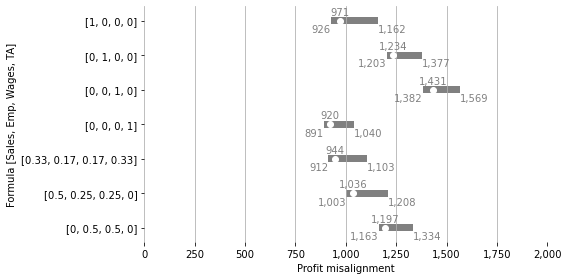

In [31]:
plt.figure(figsize=(8,4))
i = 0
for alpha in d_results:
    i += 1
    d = d_results[alpha].copy()#.xs(i, level='Domestic', drop_level=False)
    d[d<0] = 0
    d = d.groupby("iso3_d").sum()
    
    perc = np.percentile(d.sum(),[2.5,50,97.5])/1E9
    print(alpha,perc)
    plt.barh(i,perc[-1]-perc[0],left=perc[0],color="gray",height=0.2)
    plt.scatter(perc[1],i,color="white",zorder=9)
    plt.annotate(f"{perc[1]:2,.0f}",(perc[1],i-0.25),va="center",ha="center",color="gray")
    plt.annotate(f"{perc[0]:2,.0f}",(perc[0],i+0.25),va="center",ha="right",color="gray")
    plt.annotate(f"{perc[-1]:2,.0f}",(perc[-1],i+0.25),va="center",ha="left",color="gray")
    
plt.yticks(range(1,i+1),[[np.round(_,2) if _!=int(_) else int(_) for _ in k] for k in d_results.keys()])
plt.gca().grid(axis="x")
sns.despine(bottom=True,left=True)
plt.xlim(0,2000)
plt.xlabel("Profit misalignment")
plt.ylabel("Formula [Sales, Emp, Wages, TA]")
plt.gca().invert_yaxis()


plt.gca().xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.savefig("/Users/javiergb/Downloads/test.png",dpi=300)